### Import Libraries

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import make_pipeline, Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.precision', 6)

In [70]:
df = pd.read_csv(r'C:\Users\user\Desktop\ML & DL projects\Anti- Money Laundering classification\data\raw\HI-Small_Trans.csv')

In [71]:
df.columns = df.columns.str.replace(' ', '_').str.replace('.', '_').str.lower()
df.head(5)

,timestamp,from_bank,account,to_bank,account_1,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [72]:
# we make a copy 
df1 = df.copy()

In [73]:
# new feature where add whether we check whether the recieved currency is same as payment currency

df1['is_currency_switch'] = np.where(df1['receiving_currency'] != df1['payment_currency'], 1, 0)

df1.head()

,timestamp,from_bank,account,to_bank,account_1,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering,is_currency_switch
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,0


In [74]:
df1.is_currency_switch.value_counts()

is_currency_switch
0    5006175
1      72170
Name: count, dtype: int64

For Fraud cases (is_laundering = 1):
 - Mismatched Currencies (0): 5177
 - Matched Currencies (1):    0


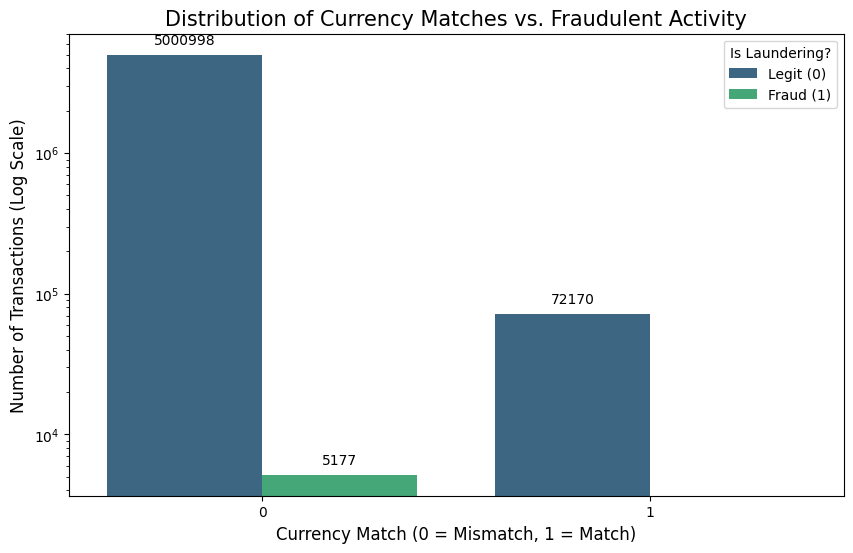

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 2. Get the raw numbers you asked for
# This shows the breakdown of matches vs mismatches specifically for fraud (is_laundering == 1)
fraud_stats = df1[df1['is_laundering'] == 1]['is_currency_switch'].value_counts()
print("For Fraud cases (is_laundering = 1):")
print(f" - Mismatched Currencies (0): {fraud_stats.get(0, 0)}")
print(f" - Matched Currencies (1):    {fraud_stats.get(1, 0)}")

# 3. Create the Split Plot (Count Plot)
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df1, x='is_currency_switch', hue='is_laundering', palette='viridis')

# Adding labels and title
plt.title('Distribution of Currency Matches vs. Fraudulent Activity', fontsize=15)
plt.xlabel('Currency Match (0 = Mismatch, 1 = Match)', fontsize=12)
plt.ylabel('Number of Transactions (Log Scale)', fontsize=12)
plt.legend(title='Is Laundering?', labels=['Legit (0)', 'Fraud (1)'])

# Using a log scale is helpful because the classes are so imbalanced
plt.yscale('log') 

# Adding value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

### inference 

- from the above plot we find that, when the recieving and payement currency are different, there is not fraud in this dataset

- whereas when the currency is the same, all the fraud cases appear in that

##### now we will seperate the time columns into different components

In [76]:
df1['timestamp'] = pd.to_datetime(df1['timestamp'])
df1['year'] = df1['timestamp'].dt.year
df1['month'] = df1['timestamp'].dt.month
df1['day'] = df1['timestamp'].dt.day

In [77]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 15 columns):
 #   Column              Dtype         
---  ------              -----         
 0   timestamp           datetime64[ns]
 1   from_bank           int64         
 2   account             object        
 3   to_bank             int64         
 4   account_1           object        
 5   amount_received     float64       
 6   receiving_currency  object        
 7   amount_paid         float64       
 8   payment_currency    object        
 9   payment_format      object        
 10  is_laundering       int64         
 11  is_currency_switch  int32         
 12  year                int32         
 13  month               int32         
 14  day                 int32         
dtypes: datetime64[ns](1), float64(2), int32(4), int64(3), object(5)
memory usage: 503.7+ MB


In [78]:
df1.drop(columns=['timestamp'], axis = 1, inplace=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 14 columns):
 #   Column              Dtype  
---  ------              -----  
 0   from_bank           int64  
 1   account             object 
 2   to_bank             int64  
 3   account_1           object 
 4   amount_received     float64
 5   receiving_currency  object 
 6   amount_paid         float64
 7   payment_currency    object 
 8   payment_format      object 
 9   is_laundering       int64  
 10  is_currency_switch  int32  
 11  year                int32  
 12  month               int32  
 13  day                 int32  
dtypes: float64(2), int32(4), int64(3), object(5)
memory usage: 464.9+ MB


In [79]:
# doing this so that I can use it for training autoencoders later on

import joblib
from joblib import dump

dump((df1), 'dataset_autoencoder1.joblib')


['dataset_autoencoder1.joblib']

In [80]:
import joblib
from joblib import load

df1 = joblib.load(r'C:\Users\user\Desktop\ML & DL projects\Anti- Money Laundering classification\notebooks\dataset_autoencoder1.joblib')

X1 = df1.drop(columns='is_laundering', axis=1)
y1 = df1['is_laundering']

X_trainA, X_testA, y_trainA, y_testA = train_test_split(X1, y1, test_size=0.2, stratify= y1)


# M-Estimate (Smoothed) Encoding: High-Cardinality Transformation

### 1. What is M-Estimate Encoding?
M-Estimate Encoding is a **supervised categorical encoding** technique. It transforms categorical labels (like Currency or Payment Method) into a single numerical column representing the "risk score" or probability of the target occurring for that category.

Unlike simple Mean Encoding, it uses **Additive Smoothing** to blend the specific category mean with the global average.

**The Formula:**
$$Encoded Value = \frac{(n \times \text{category\_mean}) + (m \times \text{global\_mean})}{n + m}$$

* **n**: The number of times the category appears in your data.
* **m**: The **smoothing parameter**. A higher *m* makes the estimate "shrink" closer to the global average.
* **category_mean**: The average target value for that specific category.
* **global_mean**: The average target value across your entire dataset.

---

### 2. Why are we using it?
In AML and Fraud detection, we often face **High Cardinality** (hundreds of currencies or IDs) and **Rare Categories** (exotic currencies used only once).

* **Prevents Overfitting on Rare Labels:** If a rare currency appears only once and happens to be fraud, its raw mean is 1.0 (100%). M-Estimate pulls this back toward the global mean (e.g., 0.05), recognizing that one sample is not a reliable trend.
* **Algorithm Agnostic:** It compresses high-cardinality features into 1 column. This makes it compatible with **Neural Networks**, **GNNs**, and **Linear Models** which struggle with the thousands of sparse columns created by One-Hot Encoding.
* **Captures Domain Risk:** It explicitly tells the model the "fraud probability" of a category, making it easier for the model to learn compared to arbitrary label encoding.

---

### 3. Why do we use `y_train`?
You might notice the code uses `encoder.fit_transform(X_train, y_train)`. Here is why `y_train` is mandatory:

* **Supervised Learning:** Because this is a *target-based* encoder, it needs to know which transactions were actually "Laundering" vs. "Legit" to calculate the `category_mean`. Without the labels (`y`), it has no "ground truth" to derive the risk score.
* **Learning the Mapping:** During the `.fit()` stage, the encoder uses `y_

In [81]:
from category_encoders import MEstimateEncoder
# 1. Initialize the encoder
# 'm' is the smoothing parameter. Higher m = more trust in the global average.
# A common starting value for m is between 1 and 10.
encoder = MEstimateEncoder(cols=['receiving_currency', 'payment_currency', 'payment_format'], m=5.0)

# 2. Fit and transform your training data
# Note: You MUST provide the target 'y' so it can calculate the risk means
X_trainB = encoder.fit_transform(X_trainA, y_trainA)
y_trainB = y_trainA.copy()
# 3. Transform your test/validation data
# This uses the mappings learned from the training set
X_testB = encoder.transform(X_testA)
y_testB = y_testA.copy()

In [83]:
X_trainB.head()

,from_bank,account,to_bank,account_1,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_currency_switch,year,month,day
4874393,18324,80CEAB990,137888,810E7BDD0,6.54,0.00,6.54,0.00,0.00,0,2022,9,10
220391,111904,80C4374B0,111904,80C4374B0,5825733.35,0.00,5825733.35,0.00,0.00,0,2022,9,1
4683703,1362,800621A50,11405,800BD0AD0,1549.25,0.00,1549.25,0.00,0.00,0,2022,9,9
1453029,240229,80EA3C100,239604,80F227470,2466.84,0.00,2466.84,0.00,0.00,0,2022,9,2
2196191,148389,81241A1A0,149971,812AA6010,3089.37,0.00,3089.37,0.00,0.00,0,2022,9,4


In [84]:
X_trainB['receiving_currency'].head(10).values

array([0.00102537, 0.00087293, 0.00102537, 0.00081396, 0.00407099,
       0.00102537, 0.00049872, 0.00102537, 0.00097426, 0.00092909])

In [85]:
import joblib
from joblib import dump

dump((X_trainB, y_trainB, X_testB, y_testB), 'ORIGINAL2_TRANSFORMED_dataset_splits.joblib')

['ORIGINAL2_TRANSFORMED_dataset_splits.joblib']

### Understampling the Dataset

We will split the data first and then perform all the required transformations and apply frequency encoding and imbalace handling techniques like SMOTE and so on. This is done to avoid Data Leakage. Here the the changes and transformation that are done on training dataset will also be performed on test dataset

In [86]:
from imblearn.under_sampling import RandomUnderSampler
import math
df_train = pd.concat([X_trainB, y_trainB], axis=1)
chunk_size = 100_000
n = len(df_train)
num_chunks = math.ceil(n / chunk_size)

rus = RandomUnderSampler(
    sampling_strategy=0.1,  # keep 10% majority
    random_state=42
)

balanced_chunks = []

for i in range(num_chunks):
    chunk = df_train.iloc[i*chunk_size : (i+1)*chunk_size]

    X_chunk = chunk.drop("is_laundering", axis=1)
    y_chunk = chunk["is_laundering"]

    if len(y_chunk.unique()) > 1:  # only process chunks with both labels
        X_res, y_res = rus.fit_resample(X_chunk, y_chunk)
        balanced_chunks.append(pd.concat([X_res, y_res], axis=1))

df_balanced1 = pd.concat(balanced_chunks, ignore_index=True)
print(df_balanced1["is_laundering"].value_counts())

is_laundering
0    41420
1     4142
Name: count, dtype: int64


In [43]:
df_balanced1.head(5)

,from_bank,account,to_bank,account_1,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_currency_switch,year,month,day,is_laundering
0,214,80B766490,231744,80BE6F320,53627.55,0.00,53627.55,0.00,0.00,0,2022,9,5,0
1,6625,802D350B0,4259,80D426340,145.62,0.00,145.62,0.00,0.01,0,2022,9,5,0
2,70,100428660,132921,8130B55B0,2501.89,0.00,2501.89,0.00,0.00,0,2022,9,8,0
3,119,810518E30,142836,810BAC5B0,23680.68,0.00,23680.68,0.00,0.00,0,2022,9,2,0
4,70,100428858,126191,809CD3B70,47723.41,0.00,47723.41,0.00,0.00,0,2022,9,6,0


In [88]:
X_trainC = df_balanced1.drop(columns='is_laundering', axis=1)
y_trainC = df_balanced1['is_laundering']

### Frequency Encoding

Frequency encoding is used for the variables from_bank, to_bank, account, and account_1 to handle their large number of unique categories. This method represents each category by its frequency in the dataset, capturing usage patterns relevant to detecting money-laundering while avoiding the high dimensionality and performance issues associated with one-hot encoding.

In [89]:
columns_to_change = ['from_bank', 'account', 'to_bank', 'account_1']
X_testC = X_testB.copy()
y_testC = y_testB.copy()
for col in columns_to_change:
    freq = X_trainC[col].value_counts(normalize=True)
    X_trainC[col] = X_trainC[col].map(freq)

    freq_test = X_testC[col].value_counts(normalize=True)
    X_testC[col] = X_testC[col].map(freq_test)

In [91]:
X_trainC.head()

,from_bank,account,to_bank,account_1,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_currency_switch,year,month,day
0,0.00,0.00,0.00,0.00,2744.75,0.00,2744.75,0.00,0.01,0,2022,9,6
1,0.00,0.00,0.00,0.00,1.84,0.00,193.94,0.00,0.01,1,2022,9,5
2,0.01,0.00,0.00,0.00,51.13,0.00,51.13,0.00,0.00,0,2022,9,1
3,0.00,0.00,0.00,0.00,129.05,0.00,129.05,0.00,0.00,0,2022,9,6
4,0.00,0.00,0.00,0.00,10220.49,0.00,10220.49,0.00,0.00,0,2022,9,7


In [48]:
X_trainC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45562 entries, 0 to 45561
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   from_bank           45562 non-null  float64
 1   account             45562 non-null  float64
 2   to_bank             45562 non-null  float64
 3   account_1           45562 non-null  float64
 4   amount_received     45562 non-null  float64
 5   receiving_currency  45562 non-null  float64
 6   amount_paid         45562 non-null  float64
 7   payment_currency    45562 non-null  float64
 8   payment_format      45562 non-null  float64
 9   is_currency_switch  45562 non-null  int32  
 10  year                45562 non-null  int32  
 11  month               45562 non-null  int32  
 12  day                 45562 non-null  int32  
dtypes: float64(9), int32(4)
memory usage: 3.8 MB


Robust scaling handles outliers better than normalization or standardization by minimizing their influence while scaling numerical features. This ensures stable transformations and preserves the integrity of the data distribution for analysis and modeling.

In [49]:
robust_scaler = RobustScaler()
columns_to_scale = ['amount_received', 'amount_paid']

X_trainC[columns_to_scale] = robust_scaler.fit_transform(X_trainC[columns_to_scale])
X_testC[columns_to_scale] = robust_scaler.transform(X_testC[columns_to_scale])

X_trainC.head()


,from_bank,account,to_bank,account_1,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_currency_switch,year,month,day
0,0.00,0.00,0.00,0.00,3.83,0.00,3.84,0.00,0.00,0,2022,9,5
1,0.00,0.00,0.00,0.00,-0.12,0.00,-0.12,0.00,0.01,0,2022,9,5
2,0.09,0.03,0.00,0.00,0.05,0.00,0.05,0.00,0.00,0,2022,9,8
3,0.00,0.00,0.00,0.00,1.62,0.00,1.62,0.00,0.00,0,2022,9,2
4,0.09,0.00,0.00,0.00,3.40,0.00,3.41,0.00,0.00,0,2022,9,6


In [90]:
dump((X_trainC, y_trainC, X_testB, y_testB), 'UNDERSAMPLED_TRANSFORMED1_dataset_splits.joblib')

['UNDERSAMPLED_TRANSFORMED1_dataset_splits.joblib']

In [50]:
import joblib
from joblib import dump

dump((X_trainC, y_trainC, X_testC, y_testC), 'COMPLETELY_TRANSFORMED_dataset_splits.joblib')

['COMPLETELY_TRANSFORMED_dataset_splits.joblib']

In [51]:
import joblib
from joblib import load

X_trainC, y_trainC, X_testC, y_testC = joblib.load(r'C:\Users\user\Desktop\ML & DL projects\Anti- Money Laundering classification\notebooks\COMPLETELY_TRANSFORMED_dataset_splits.joblib')

In [52]:
## we are using smotetomek and checking another kind of dataset
smt = SMOTETomek(sampling_strategy=0.4, random_state=42)
X_train2, y_train2 = smt.fit_resample(X_trainC, y_trainC)

In [53]:
smt2 = SMOTEENN(sampling_strategy=0.4, random_state=42)
X_train3, y_train3 = smt2.fit_resample(X_trainC, y_trainC)

In [54]:
smt3 = SMOTE(sampling_strategy=0.4, random_state=42)
X_train4, y_train4 = smt3.fit_resample(X_trainC, y_trainC)

In [55]:
y_train2.value_counts()

is_laundering
0    40004
1    15152
Name: count, dtype: int64

In [56]:
X_train2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55156 entries, 0 to 55155
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   from_bank           55156 non-null  float64
 1   account             55156 non-null  float64
 2   to_bank             55156 non-null  float64
 3   account_1           55156 non-null  float64
 4   amount_received     55156 non-null  float64
 5   receiving_currency  55156 non-null  float64
 6   amount_paid         55156 non-null  float64
 7   payment_currency    55156 non-null  float64
 8   payment_format      55156 non-null  float64
 9   is_currency_switch  55156 non-null  int32  
 10  year                55156 non-null  int32  
 11  month               55156 non-null  int32  
 12  day                 55156 non-null  int32  
dtypes: float64(9), int32(4)
memory usage: 4.6 MB


In [57]:
df3 = pd.concat([X_train2, y_train2], axis=1)

In [58]:
df3.head()

,from_bank,account,to_bank,account_1,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_currency_switch,year,month,day,is_laundering
0,0.00,0.00,0.00,0.00,3.83,0.00,3.84,0.00,0.00,0,2022,9,5,0
1,0.00,0.00,0.00,0.00,-0.12,0.00,-0.12,0.00,0.01,0,2022,9,5,0
2,0.09,0.03,0.00,0.00,0.05,0.00,0.05,0.00,0.00,0,2022,9,8,0
3,0.00,0.00,0.00,0.00,1.62,0.00,1.62,0.00,0.00,0,2022,9,2,0
4,0.09,0.00,0.00,0.00,3.40,0.00,3.41,0.00,0.00,0,2022,9,6,0


In [59]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55156 entries, 0 to 55155
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   from_bank           55156 non-null  float64
 1   account             55156 non-null  float64
 2   to_bank             55156 non-null  float64
 3   account_1           55156 non-null  float64
 4   amount_received     55156 non-null  float64
 5   receiving_currency  55156 non-null  float64
 6   amount_paid         55156 non-null  float64
 7   payment_currency    55156 non-null  float64
 8   payment_format      55156 non-null  float64
 9   is_currency_switch  55156 non-null  int32  
 10  year                55156 non-null  int32  
 11  month               55156 non-null  int32  
 12  day                 55156 non-null  int32  
 13  is_laundering       55156 non-null  int64  
dtypes: float64(9), int32(4), int64(1)
memory usage: 5.0 MB


In [63]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import numpy as np
import pandas as pd

def calculate_vif(df, target_col):
    # 1. Drop the target and non-numeric columns
    numeric_df = df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    
    # 2. Add the constant
    # has_constant='add' forces it to add the column even if it thinks one exists
    X = add_constant(numeric_df, has_constant='add')
    
    vif_data = pd.DataFrame()
    # We want to calculate VIF for the ORIGINAL columns only (excluding the constant)
    vif_data["feature"] = numeric_df.columns
    
    # 3. Use the actual column name to find the index in X
    # This prevents the "index + 1" math errors entirely
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, X.columns.get_loc(col)) 
        for col in numeric_df.columns
    ]
    
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

df4 = df3.copy()
# Try it now
vif_table = calculate_vif(df4, target_col="is_laundering")
print(vif_table)

               feature     VIF
0      amount_received 1342.01
1          amount_paid 1342.01
2     payment_currency  108.37
3   receiving_currency  108.29
4            from_bank    2.84
5              account    2.79
6       payment_format    1.32
7            account_1    1.27
8                  day    1.08
9   is_currency_switch    1.04
10             to_bank    1.02
11                year    0.00
12               month    0.00


In [64]:
# Create a cleaned version of your dataframe
df_clean = df4.drop(columns=[
    'amount_paid',       # Redundant with amount_received
    'payment_currency',  # Redundant with receiving_currency + is_currency_switch
    'year',              # Constant value (0 variance)
    'month'              # Constant value (0 variance)
])

print(f"Original features: {df4.shape[1]}")
print(f"Cleaned features:  {df_clean.shape[1]}")

Original features: 14
Cleaned features:  10


In [65]:
vif_table = calculate_vif(df_clean, target_col="is_laundering")
print(vif_table)

              feature  VIF
0           from_bank 2.84
1             account 2.78
2      payment_format 1.32
3           account_1 1.26
4  receiving_currency 1.09
5                 day 1.08
6  is_currency_switch 1.03
7             to_bank 1.02
8     amount_received 1.00


In [56]:
import joblib
from joblib import dump

dump((X_train1, y_train1, X_test1, y_test1), 'dataset_splits.joblib')


['dataset_splits.joblib']

In [66]:
# for smoteEK applied one
import joblib
from joblib import dump

dump((X_train2, y_train2, X_testC, y_testC), 'SMOTETEEK2_dataset_splits.joblib')

['SMOTETEEK2_dataset_splits.joblib']

In [67]:
# FOR SMOTE 
import joblib
from joblib import dump

dump((X_train4, y_train4, X_testC, y_testC), 'SMOTE2_dataset_splits.joblib')

['SMOTE2_dataset_splits.joblib']

In [68]:
# FOR SMOTE 
import joblib
from joblib import dump

dump((X_train3, y_train3, X_testC, y_testC), 'SMOTEENN2_dataset_splits.joblib')

['SMOTEENN2_dataset_splits.joblib']

In [3]:
# importing the datasets

import joblib
from joblib import load

X_train1, y_train1, X_test1, y_test1 = joblib.load(r'C:\Users\user\Desktop\ML & DL projects\Anti- Money Laundering classification\dataset_joblib_files\dataset_splits.joblib')